In [1]:
print(1%50)
print(51%50)

1
1


In [2]:
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

import numpy as np
import matplotlib.pyplot as plt
import mediapy

sim = MiniprojectSimulation(level=2, seed=20)
# RETOURNEMENT seed=20
controller = Controller(sim, threshold_line = 40, mode="adapts_ROI not derivative", pitch_weight=150)
# modes : "tuning ROi" , "tuning slope" , "adapts_ROI derivative", "writing anythin else just not to be in these modes"

for k in trange(40000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.render_as_needed()
    sim.step()

mediapy.show_video(controller.frames, fps=sim.renderer.output_fps, title="ommatidia vision")
sim.renderer.show_in_notebook()

100%|██████████| 40000/40000 [00:54<00:00, 733.51it/s]


ommatidia vision This browser does not support the video tag.


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


(512, 900, 3)


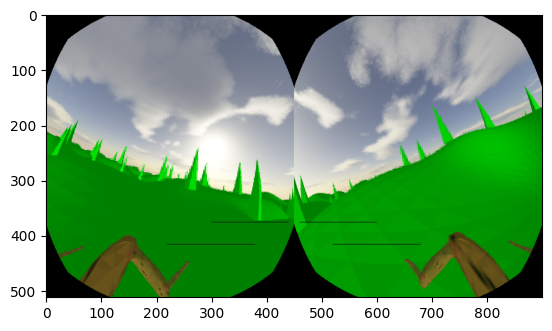

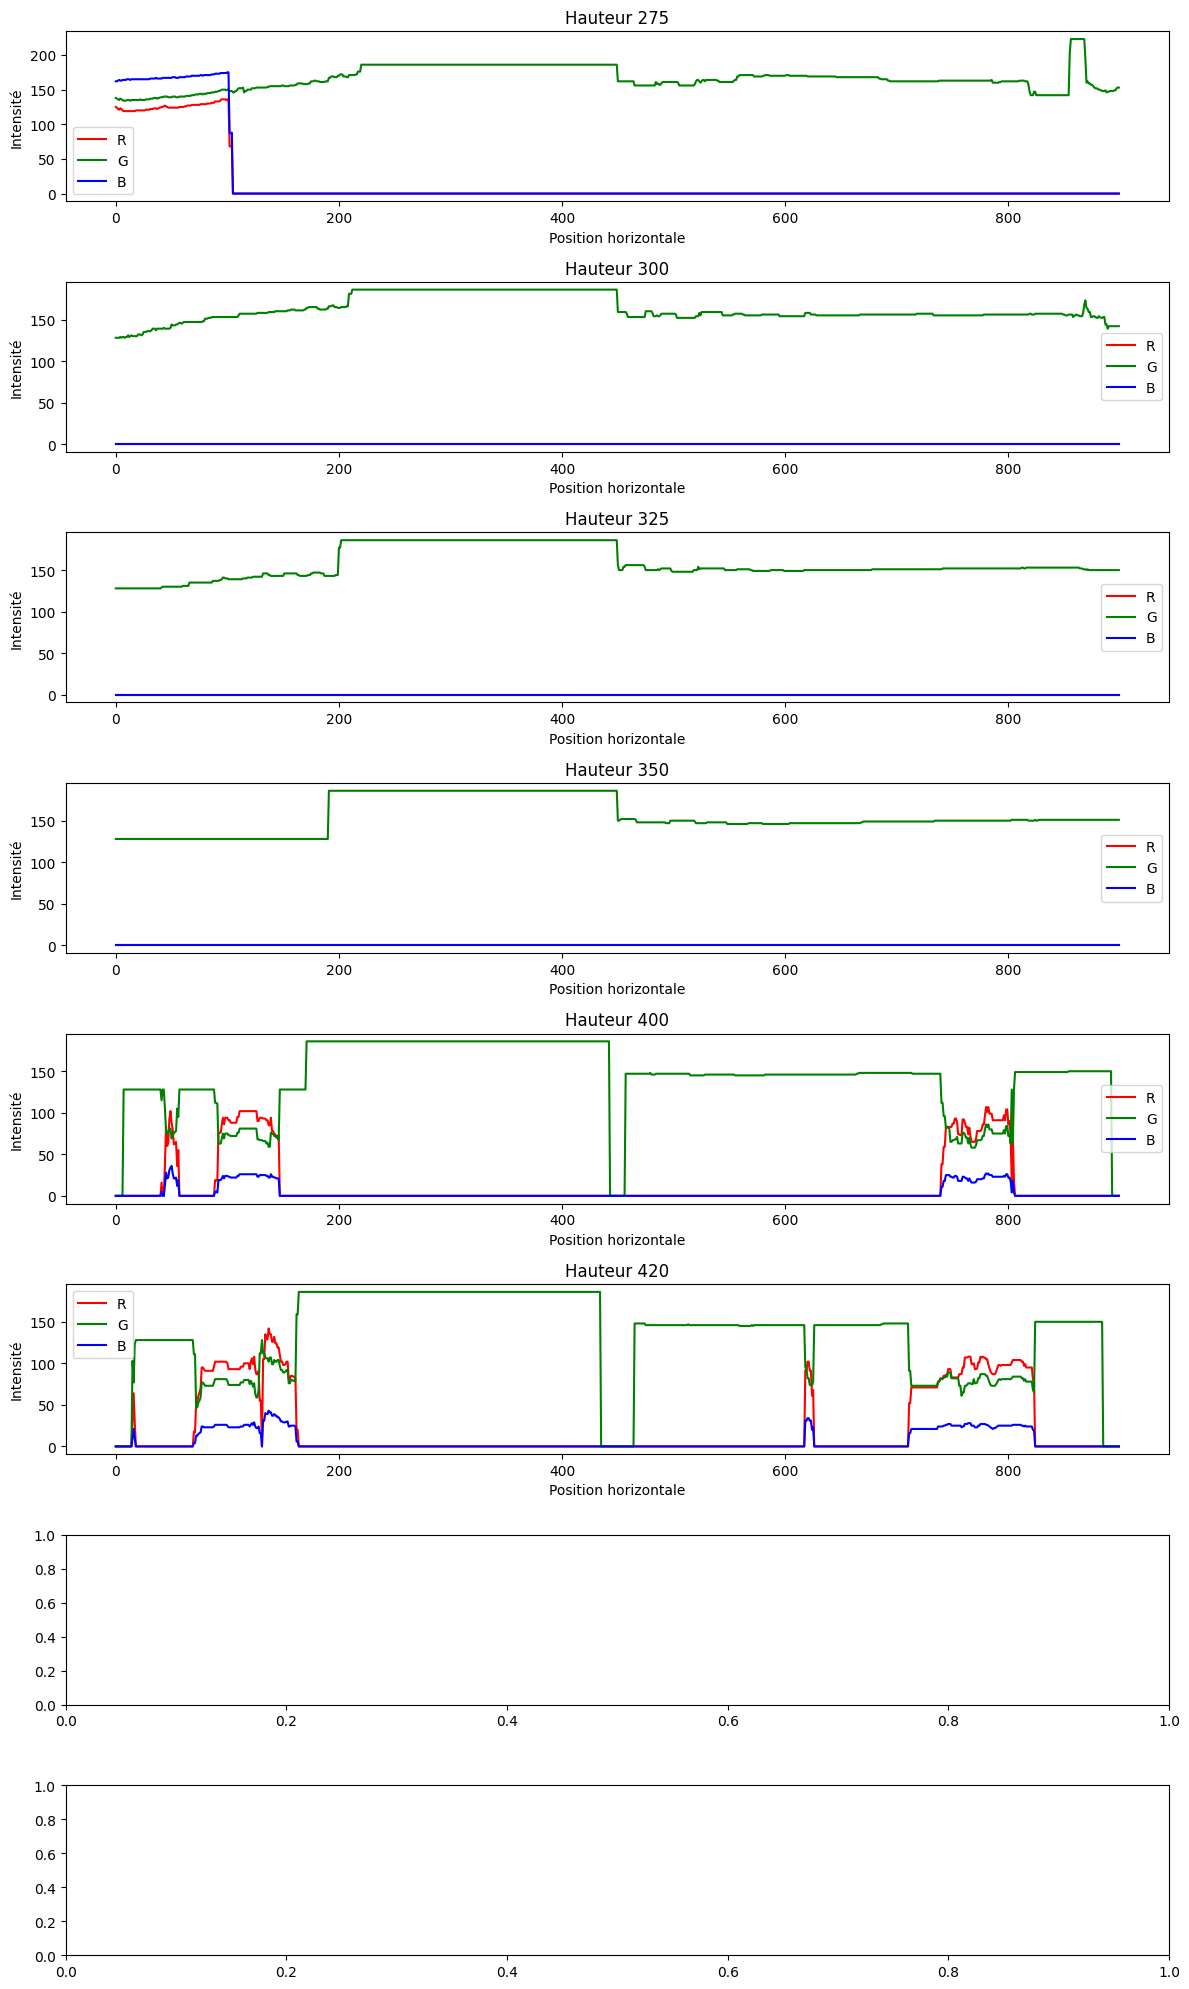

In [3]:
###########################################################
#################### DEBUGG ADRI ##########################
###########################################################


print(controller.frames[0].shape)
plt.imshow(controller.frames[0])
"""
print("controller.ratio :", controller.ratio)

print(np.array(controller.ratio))

n= 5 # for the last 5 tuples
print("ratio mean", np.mean([x[2] for x in controller.ratio[-n:]]))


for i in range(900):
    if controller.frames[0][300, i][1] > 80:
        controller.frames[0][300, i] = [0, 0, 128] # for debugg
    
    if controller.frames[0][300, i][1] > 20:
        controller.frames[0][300, i] = [255, 0, 0] # for debugg
    
    controller.frames[0][100, i] = [0, 255, 0] # juste pr voir ce que ca fait green 255
"""


image = controller.frames[-1]  # ton image
heights = [275, 300, 325, 350, 400, 420]

fig, axes = plt.subplots(8, 1, figsize=(12, 20))

for idx, h in enumerate(heights):
    line = image[h, :, :]  # tous les pixels à la hauteur h, shape (900, 3)
    
    axes[idx].plot(line[:, 0], color='red',   label='R')
    axes[idx].plot(line[:, 1], color='green', label='G')
    axes[idx].plot(line[:, 2], color='blue',  label='B')
    
    axes[idx].set_title(f'Hauteur {h}')
    axes[idx].set_xlabel('Position horizontale')
    axes[idx].set_ylabel('Intensité')
    axes[idx].legend()

plt.tight_layout()
plt.show()
